In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import math
import shutil
import models as m

torch.set_default_dtype(torch.float32)

if torch.cuda.is_available(): 
    device = torch.device('cuda:0')
elif torch.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

def t(x):
    return torch.as_tensor(x, dtype=torch.get_default_dtype()).to(device)

print("Device:", device)

Device: mps


#### Load RUN

In [2]:
BASE_PATH = os.getcwd()
RUNS_ROOT = os.path.join(BASE_PATH, "runs")

EXP_NAME = "gmm_baseline"
RUN_ID   = "004"   # À changer selon le run
RUN_DIR = os.path.join(RUNS_ROOT, EXP_NAME, RUN_ID)

FIG_DIR     = os.path.join(RUN_DIR, "figures")
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
LOGS_DIR    = os.path.join(RUN_DIR, "logs")

print("RUN_DIR:", RUN_DIR)

RUN_DIR: /Users/rplanchon/Documents/MVA/Cours/S1/ProbGraphModel/Projet/DSM/src/ncsn/gmm/runs/gmm_baseline/004


In [3]:
with open(os.path.join(LOGS_DIR, "hparams.json"), "r") as f:
    hparams = json.load(f)

sigmas = torch.from_numpy(
    np.load(os.path.join(LOGS_DIR, "sigmas.npy"))
).to(device)

train_loss = np.load(os.path.join(LOGS_DIR, "train_loss.npy"))
train_loss_per_sigma = np.load(
    os.path.join(LOGS_DIR, "train_loss_per_sigma.npy")
)
steps_eval = np.load(os.path.join(LOGS_DIR, "steps_eval.npy"))

print("sigmas:", sigmas)
print("train_loss shape:", train_loss.shape)
print("train_loss_per_sigma shape:", train_loss_per_sigma.shape)

sigmas: tensor([10.0000,  5.9948,  3.5938,  2.1544,  1.2915,  0.7743,  0.4642,  0.2783,
         0.1668,  0.1000], device='mps:0')
train_loss shape: (40000,)
train_loss_per_sigma shape: (40, 10)


#### Plot training curves

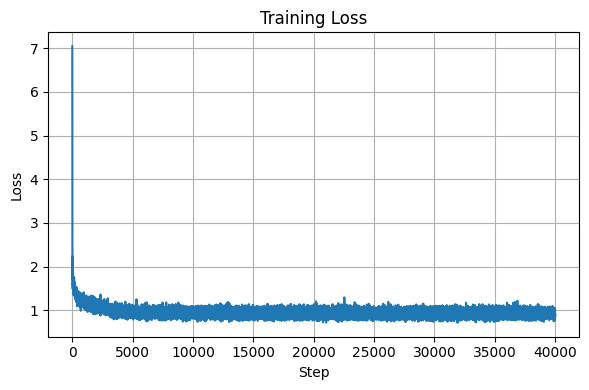

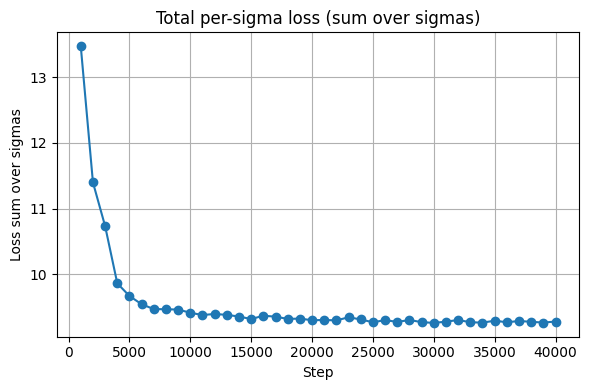

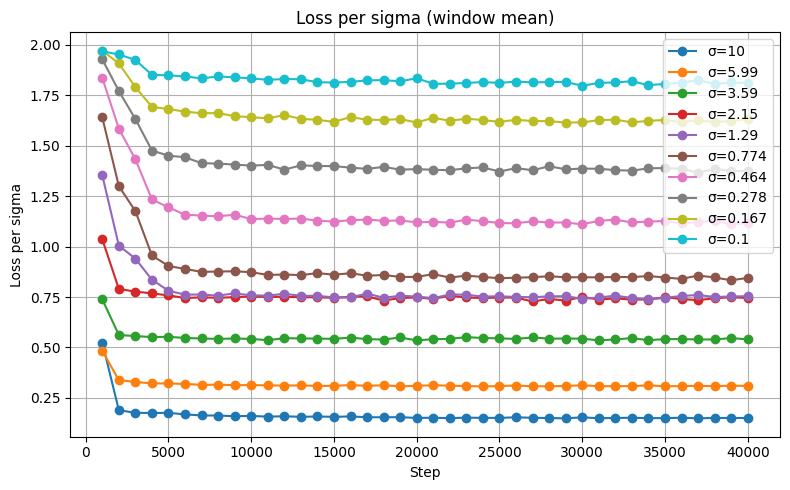

In [4]:
plt.figure(figsize=(6,4))
plt.title("Training Loss")
plt.plot(train_loss)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eval_train_loss.png"), dpi=200)
plt.show()

total_per_sigma = train_loss_per_sigma.sum(axis=1)

plt.figure(figsize=(6,4))
plt.title("Total per-sigma loss (sum over sigmas)")
plt.plot(steps_eval, total_per_sigma, marker='o')
plt.xlabel("Step")
plt.ylabel("Loss sum over sigmas")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eval_total_sigma_loss.png"), dpi=200)
plt.show()

plt.figure(figsize=(8,5))
for j in range(len(sigmas)):
    plt.plot(
        steps_eval,
        train_loss_per_sigma[:, j],
        marker='o',
        label=f"σ={float(sigmas[j]):.3g}"
    )
plt.legend()
plt.title("Loss per sigma (window mean)")
plt.xlabel("Step")
plt.ylabel("Loss per sigma")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eval_loss_per_sigma.png"), dpi=200)
plt.show()

#### Rebuild dataset GMM from saved hparams

In [5]:
ds_cfg = hparams["dataset"]
mean_arr    = np.array(ds_cfg["mean"], dtype=np.float32)      # (K,2)
cov_arr     = np.array(ds_cfg["cov"], dtype=np.float32)       # (K,2,2)
weights_arr = np.array(ds_cfg["weights"], dtype=np.float32)   # (K,)

mean = torch.tensor(mean_arr, device=device)
cov  = torch.tensor(cov_arr, device=device)
w    = torch.tensor(weights_arr, device=device)

weights = dist.Categorical(w)
gaussians = dist.MultivariateNormal(mean, cov)
dataset = dist.MixtureSameFamily(weights, gaussians)

def construct_GMM_noised_distribution(noise_list, loc, cov, weights):
    noised = []
    d = loc.size(-1)
    for sigma in noise_list:
        g = dist.MultivariateNormal(
            loc,
            cov + torch.eye(d, device=device) * sigma**2
        )
        noised.append(dist.MixtureSameFamily(weights, g))
    return noised

def score(distrib, x):
    x = x.clone().detach().requires_grad_(True)
    lp = distrib.log_prob(x)
    s, = torch.autograd.grad(lp.sum(), x)
    return s

true_noised_dist = construct_GMM_noised_distribution(
    sigmas, mean, cov, weights
)
true_distribution_scores = [ (lambda d: (lambda x: score(d,x)))(d)
                             for d in true_noised_dist ]

#### Load model + estimated scores

In [6]:
x_dim        = hparams["model"]["x_dim"]
HIDDEN_DIM   = hparams["model"]["hidden_dim"]
SIGMA_EMB_DIM= hparams["model"]["sigma_emb_dim"]

model = m.ScoreNetworkConditionned1(
    x_dim=x_dim,
    hidden_dim=HIDDEN_DIM,
    sigma_emb_dim=SIGMA_EMB_DIM
).to(device)

state_dict = torch.load(
    os.path.join(WEIGHTS_DIR, "model.pt"),
    map_location=device
)
model.load_state_dict(state_dict)
model.eval()

def make_score_from_model(model, sigma_scalar):
    sigma_scalar = float(sigma_scalar)
    @torch.no_grad()
    def s(x):
        B = x.shape[0]
        sigma = x.new_full((B, 1), sigma_scalar)
        return model(x, sigma)
    return s

estimated_distribution_scores = [
    make_score_from_model(model, s) for s in list(sigmas)
]

#### Score norm per sigma

In [7]:
SCORE_NORM = []
N_norm = 10000

with torch.no_grad():
    for i, score_i in enumerate(estimated_distribution_scores):
        x_s = true_noised_dist[i].sample((N_norm,)).to(device)
        sc  = score_i(x_s)
        SCORE_NORM.append((sc**2).sum(1).mean().item())

SCORE_NORM = np.array(SCORE_NORM)
np.save(os.path.join(LOGS_DIR, "score_norm_eval.npy"), SCORE_NORM)
print("Score norm per sigma:", SCORE_NORM)

Score norm per sigma: [ 0.01857469  0.0457958   0.11117927  0.26447687  0.7497589   1.87567461
  3.88096166  7.60404062 11.19289017 13.56353092]


#### Vector field plots 

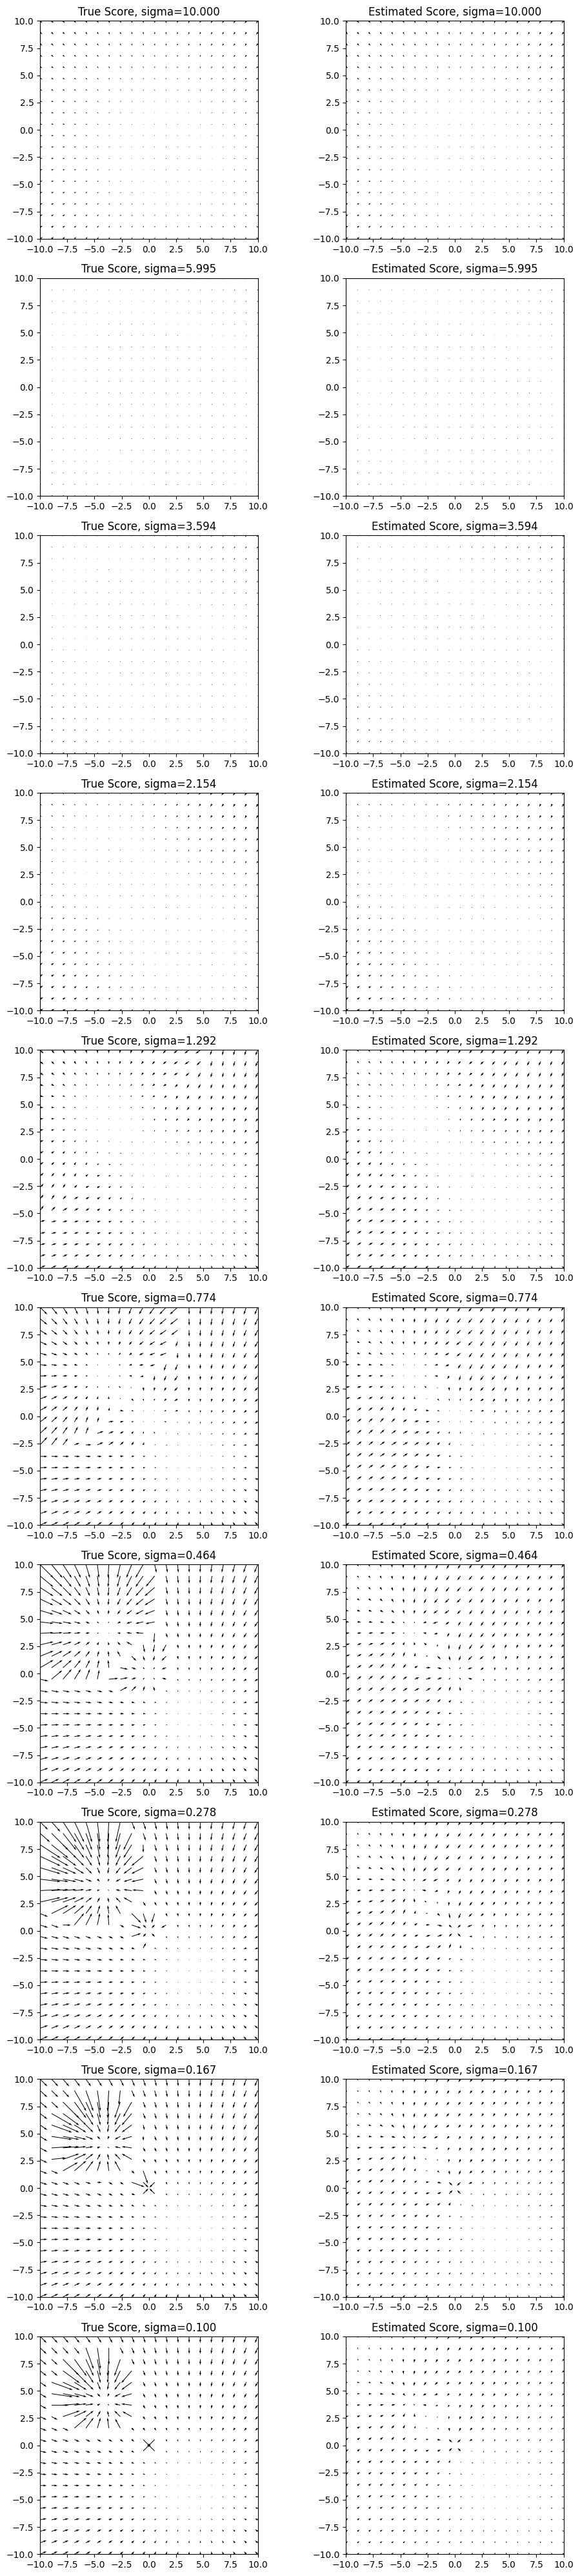

In [8]:
def plot_scores_as_vectors(true_score, estimated_score, sigmas):
    n_points = 20
    x_min, x_max = -10, 10
    xc = torch.linspace(x_min, x_max, n_points, device=device)
    yc = torch.linspace(x_min, x_max, n_points, device=device)
    
    X, Y = torch.meshgrid([xc, yc], indexing='ij')
    coords = torch.stack([X, Y], dim=-1)      # (n_points, n_points, 2)
    coords_flat = coords.view(-1, 2)          # (B, 2)
    nrows = len(sigmas)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=2,
        figsize=(10, 4 * nrows),
        squeeze=False
    )
    
    for i, s in enumerate(sigmas):
        true_score_flat_i      = true_score[i](coords_flat)
        estimated_score_flat_i = estimated_score[i](coords_flat)

        true_score_i      = true_score_flat_i.view(n_points, n_points, 2)
        estimated_score_i = estimated_score_flat_i.view(n_points, n_points, 2)

        Sx_TS = true_score_i[..., 0].cpu().detach()
        Sy_TS = true_score_i[..., 1].cpu().detach()
        Sx_ES = estimated_score_i[..., 0].cpu().detach()
        Sy_ES = estimated_score_i[..., 1].cpu().detach()

        X_cpu = X.cpu()
        Y_cpu = Y.cpu()

        ax_true = axes[i, 0]
        ax_est  = axes[i, 1]

        ax_true.set_xlim(x_min, x_max)
        ax_true.set_ylim(x_min, x_max)

        # scaling original
        h = np.log(25) / nrows
        scale1 = 0.5 + 25 * i / nrows
        scale2 = 0.5 - 1 + np.exp(h * i)  # dispo si tu veux l'utiliser plus tard

        ax_true.quiver(
            X_cpu, Y_cpu, Sx_TS, Sy_TS,
            angles='xy', scale_units='xy', scale=scale1
        )
        ax_true.set_aspect('equal')
        ax_true.set_title(f"True Score, sigma={float(s):.3f}")

        ax_est.set_xlim(x_min, x_max)
        ax_est.set_ylim(x_min, x_max)
        ax_est.quiver(
            X_cpu, Y_cpu, Sx_ES, Sy_ES,
            angles='xy', scale_units='xy', scale=scale1
        )
        ax_est.set_aspect('equal')
        ax_est.set_title(f"Estimated Score, sigma={float(s):.3f}")
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "eval_scores_vectors.png"), dpi=200)
    plt.show()

plot_scores_as_vectors(true_distribution_scores, estimated_distribution_scores, sigmas)

#### Norme du score (true vs estimated)

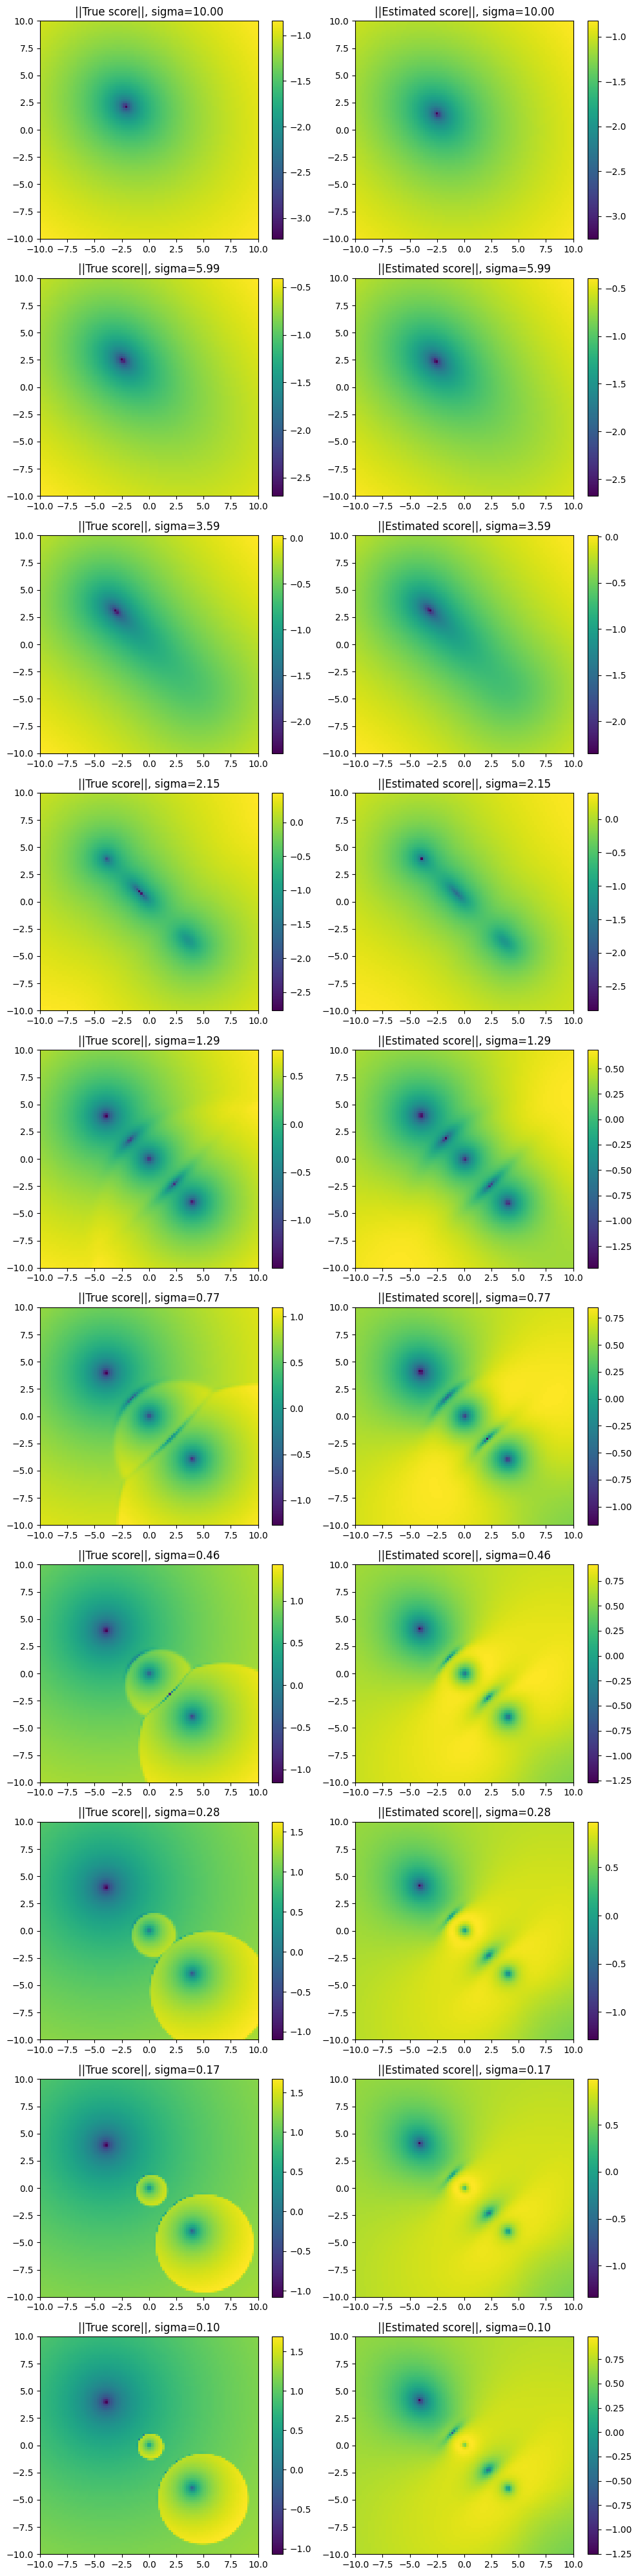

In [9]:
def plot_scores_norm(true_score, estimated_score, sigmas):
    n_points = 100
    x_min, x_max = -10, 10
    xc = torch.linspace(x_min, x_max, n_points, device=device)
    yc = torch.linspace(x_min, x_max, n_points, device=device)
    X, Y = torch.meshgrid(xc, yc, indexing='ij')
    coords = torch.stack([X, Y], dim=-1)
    coords_flat = coords.view(-1, 2)

    nrows = len(sigmas)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=2,
        figsize=(10, 4 * nrows),
        squeeze=False
    )

    eps = 1e-8
    
    for i, s in enumerate(sigmas):
        ts_flat = true_score[i](coords_flat)
        es_flat = estimated_score[i](coords_flat)

        ts = ts_flat.view(n_points, n_points, 2)
        es = es_flat.view(n_points, n_points, 2)

        mag_ts = torch.linalg.norm(ts, dim=-1).cpu()
        mag_es = torch.linalg.norm(es, dim=-1).cpu()

        log_mag_ts = (mag_ts + eps).log10()
        log_mag_es = (mag_es + eps).log10()

        ax_true = axes[i, 0]
        ax_est  = axes[i, 1]

        ax_true.set_xlim(x_min, x_max)
        ax_true.set_ylim(x_min, x_max)
        im0 = ax_true.imshow(
            log_mag_ts,
            origin='lower',
            extent=[x_min, x_max, x_min, x_max]
        )
        ax_true.set_title(f"||True score||, sigma={float(s):.2f}")
        plt.colorbar(im0, ax=ax_true)

        ax_est.set_xlim(x_min, x_max)
        ax_est.set_ylim(x_min, x_max)
        im1 = ax_est.imshow(
            log_mag_es,
            origin='lower',
            extent=[x_min, x_max, x_min, x_max]
        )
        ax_est.set_title(f"||Estimated score||, sigma={float(s):.2f}")
        plt.colorbar(im1, ax=ax_est)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "eval_scores_norm.png"), dpi=200)
    plt.show()

plot_scores_norm(true_distribution_scores, estimated_distribution_scores, sigmas)

#### Annealed Langevin Sampling (ALD)

In [10]:
def annealed_langevin_sampler_snr(
    prior, noisy_distrib_scores, noise_factor,
    SNR, norm, T, n_chain,
    save_dir=None, plot=False
):
    D = 2
    X = prior.sample((n_chain,)).to(device)
    PLOT_STEP_EVERY = T - 1
    
    if save_dir is not None:
        if os.path.exists(save_dir):
            shutil.rmtree(save_dir)
        os.makedirs(save_dir)
        plot = True

    frame = 0

    for i in range(len(noisy_distrib_scores)):
        tau = 2 * D * SNR / norm[i]
        noise_std = math.sqrt(2 * tau)

        for step in range(T):
            X = X + tau * noisy_distrib_scores[i](X) + noise_std * torch.randn_like(X)

            if plot and (step % PLOT_STEP_EVERY == 0):
                plt.figure(figsize=(5,5))
                plt.xlim(-20, 20)
                plt.ylim(-20, 20)
                plt.scatter(X[:, 0].cpu(), X[:, 1].cpu())
                plt.title(
                    f"sigma={noise_factor[i]:.3f} | "
                    f"SNR={SNR:.2e} | "
                    f"noise_std={noise_std:.2e}"
                )

                if save_dir is not None:
                    fname = os.path.join(save_dir, f"frame_{frame:05d}.png")
                    plt.savefig(fname, dpi=150)
                    plt.close()
                else:
                    plt.show()

                frame += 1

    # si tu veux une vidéo, tu peux appeler ici ton script shell
    # if save_dir is not None:
    #     os.system(f"./make_ald_video.sh {save_dir} {SNR} {T}")

    return X

In [11]:
ALD_prior_mean = [0.0, 0.0]
ALD_prior_cov_scalar = 3.0
ALD_T = 10
ALD_n_chain = 2000
SNR = 0.1

prior_mean = t(ALD_prior_mean)
prior_var  = ALD_prior_cov_scalar * torch.eye(2, device=device)
prior_distrib = dist.MultivariateNormal(prior_mean, covariance_matrix=prior_var)

ALD_estimated_score = annealed_langevin_sampler_snr(
    prior_distrib,
    estimated_distribution_scores,
    sigmas,
    SNR,
    SCORE_NORM,
    ALD_T,
    ALD_n_chain,
    save_dir=None,
    plot=False
)

ALD_true_score = annealed_langevin_sampler_snr(
    prior_distrib,
    true_distribution_scores,
    sigmas,
    SNR,
    SCORE_NORM,
    ALD_T,
    ALD_n_chain,
    save_dir=None,
    plot=False
)

#### Scatter final : true vs ALD estimated vs ALD true

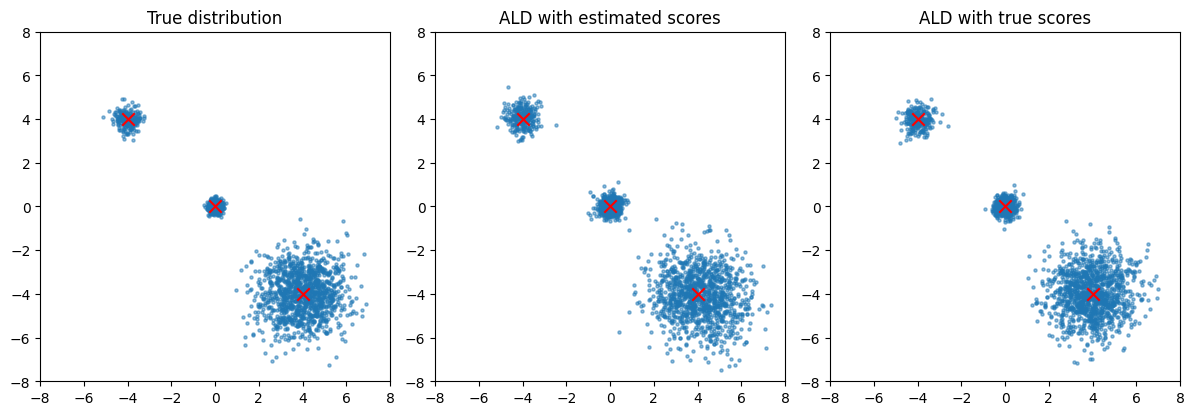

In [14]:
true_samples = dataset.sample((ALD_n_chain,)).cpu()
ALD_TS_cpu   = ALD_true_score.cpu()
ALD_ES_cpu   = ALD_estimated_score.cpu()

means_cpu = mean.detach().cpu()   # (K,2)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.scatter(true_samples[:, 0], true_samples[:, 1], s=5, alpha=0.5)
plt.scatter(means_cpu[:, 0], means_cpu[:, 1], c='red', marker='x', s=80, label="means")
plt.title("True distribution")
plt.gca().set_aspect('equal')

plt.subplot(1,3,2)
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.scatter(ALD_ES_cpu[:, 0], ALD_ES_cpu[:, 1], s=5, alpha=0.5)
plt.scatter(means_cpu[:, 0], means_cpu[:, 1], c='red', marker='x', s=80)
plt.title("ALD with estimated scores")
plt.gca().set_aspect('equal')

plt.subplot(1,3,3)
plt.xlim(-8, 8)
plt.ylim(-8, 8)
plt.scatter(ALD_TS_cpu[:, 0], ALD_TS_cpu[:, 1], s=5, alpha=0.5)
plt.scatter(means_cpu[:, 0], means_cpu[:, 1], c='red', marker='x', s=80)
plt.title("ALD with true scores")
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "eval_ALD.png"), dpi=200)
plt.show()


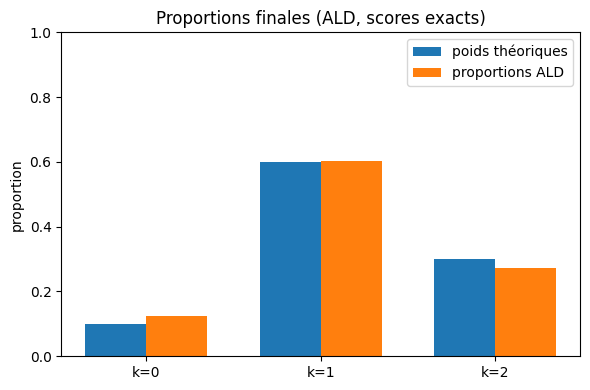

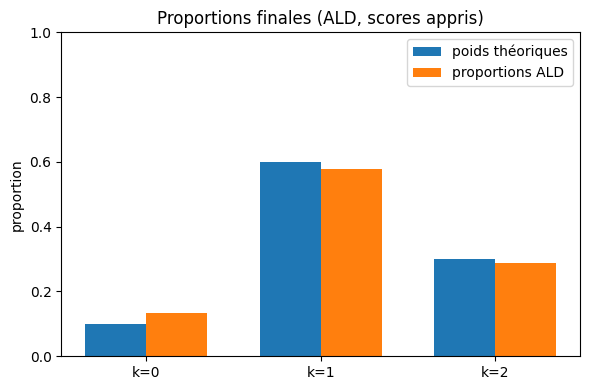

In [13]:
# %% [markdown]
# #### Histogrammes des proportions finales (ALD) vs poids théoriques

# %%
def assign_clusters(x, means):
    """
    Assigne chaque point au cluster de moyenne la plus proche (distance euclidienne).
    x: (N, 2), means: (K, 2)
    retourne un tensor (N,) d'indices dans {0,...,K-1}
    """
    x = x.to(means.device)
    x_exp = x.unsqueeze(1)        # (N, 1, 2)
    m_exp = means.unsqueeze(0)    # (1, K, 2)
    dist2 = ((x_exp - m_exp) ** 2).sum(dim=-1)  # (N, K)
    return dist2.argmin(dim=1)    # (N,)

def plot_cluster_hist(samples, means, true_weights, title, fname):
    """
    Compare proportions empiriques des clusters vs poids théoriques.
    - samples: (N, 2) tensor (cpu ou gpu)
    - means:   (K, 2) tensor
    - true_weights: (K,) tensor des poids théoriques
    """
    samples = samples.detach().cpu()
    means_cpu = means.detach().cpu()
    true_w = true_weights.detach().cpu().numpy()

    # assignation clusters
    clusters = assign_clusters(samples, means_cpu)  # (N,)
    K = means_cpu.size(0)
    counts = torch.bincount(clusters, minlength=K).float()
    emp = (counts / counts.sum()).numpy()

    idx = np.arange(K)
    width = 0.35

    plt.figure(figsize=(6,4))
    plt.bar(idx - width/2, true_w, width, label="poids théoriques")
    plt.bar(idx + width/2, emp,    width, label="proportions ALD")
    plt.xticks(idx, [f"k={i}" for i in range(K)])
    plt.ylim(0, 1.0)
    plt.ylabel("proportion")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=200)
    plt.show()

# %%
# Histogramme pour ALD avec scores exacts
plot_cluster_hist(
    ALD_true_score,     # tensor (N,2) déjà calculé plus haut
    mean,               # centres des gaussiennes (K,2)
    w,                  # poids théoriques (K,)
    title="Proportions finales (ALD, scores exacts)",
    fname="ALD_hist_true_vs_theory.png"
)

# Histogramme pour ALD avec scores appris
plot_cluster_hist(
    ALD_estimated_score,
    mean,
    w,
    title="Proportions finales (ALD, scores appris)",
    fname="ALD_hist_estimated_vs_theory.png"
)
